Rotation GIF created successfully: rotation.gif

2. Image not found.
Put an image in this folder and change image_path.


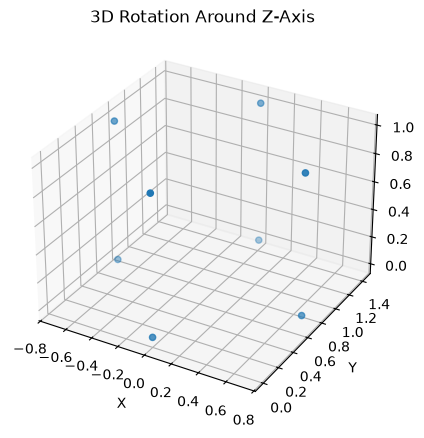


3. 3D rotation completed

4. Reflection twice
Returns to original? True
F @ F =
[[1 0]
 [0 1]]
Is identity? True

5. Affine transformation
Original point: [2 3]
New point: [4 4]
3×3 matrix allows translation.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# Define the house shape
shape = np.array([
    [0, 2, 2, 0, 0, 1, 2, 1, 0],
    [0, 0, 1, 1, 0, 1, 1, 2, 1]
], dtype=float)


# =========================================================
# 1. ANIMATE ROTATION
# =========================================================

frames = []

for angle in range(0, 361, 10):

    theta = np.radians(angle)

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    rotated = R @ shape

    fig, ax = plt.subplots(figsize=(5, 5))

    ax.plot(rotated[0], rotated[1], marker="o")
    ax.set_title(f"Rotation: {angle}°")
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.grid(True)

    filename = f"rotation_{angle}.png"
    plt.savefig(filename)
    plt.close()

    frames.append(Image.open(filename))

# Create GIF
frames[0].save(
    "rotation.gif",
    save_all=True,
    append_images=frames[1:],
    duration=100,
    loop=0
)

# Delete temporary images
for angle in range(0, 361, 10):
    os.remove(f"rotation_{angle}.png")

print("Rotation GIF created successfully: rotation.gif")


# =========================================================
# 2. APPLY TRANSFORMATION TO AN ACTUAL IMAGE
# =========================================================

# Change this to your image filename
image_path = "CRMERP.jpg"

if os.path.exists(image_path):

    image = Image.open(image_path).convert("RGB")
    image_array = np.array(image)

    # Example: horizontal shear
    M = np.array([
        [1, 0.5],
        [0, 1]
    ])

    # Display original image
    plt.figure(figsize=(6, 4))
    plt.imshow(image_array)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

    print("2. Image loaded as NumPy array")
    print("Image shape:", image_array.shape)

else:
    print("\n2. Image not found.")
    print("Put an image in this folder and change image_path.")


# =========================================================
# 3. 3D ROTATION AROUND Z-AXIS
# =========================================================

# Simple 3D cube points
points = np.array([
    [0, 1, 1, 0, 0, 1, 1, 0],
    [0, 0, 1, 1, 0, 0, 1, 1],
    [0, 0, 0, 0, 1, 1, 1, 1]
], dtype=float)

angle = np.radians(45)

Rz = np.array([
    [np.cos(angle), -np.sin(angle), 0],
    [np.sin(angle),  np.cos(angle), 0],
    [0,              0,             1]
])

rotated_points = Rz @ points

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    rotated_points[0],
    rotated_points[1],
    rotated_points[2]
)

ax.set_title("3D Rotation Around Z-Axis")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

print("\n3. 3D rotation completed")


# =========================================================
# 4. APPLY A TRANSFORMATION TWICE
# =========================================================

# Reflection across x-axis
F = np.array([
    [1, 0],
    [0, -1]
])

once = F @ shape
twice = F @ once

print("\n4. Reflection twice")
print("Returns to original?", np.allclose(twice, shape))

# Check the matrix itself
print("F @ F =")
print(F @ F)

print("Is identity?", np.allclose(F @ F, np.eye(2)))


# =========================================================
# 5. AFFINE TRANSFORMATION USING 3×3 MATRIX
# =========================================================

# Point in 2D
point = np.array([2, 3, 1])

# Translation: x + 2, y + 1
T = np.array([
    [1, 0, 2],
    [0, 1, 1],
    [0, 0, 1]
])

new_point = T @ point

print("\n5. Affine transformation")
print("Original point:", point[:2])
print("New point:", new_point[:2])
print("3×3 matrix allows translation.")